# Cell type signatures in scRNA-seq

This notebook evaluatues expression of marker genes in the scRNA-seq dataset.

## Input

- Scanpy object generated in notebook 6 (scRNA.h5ad)
- *Table S2. List of Stage-Specific Signature Genes* from [Xie et al. 2013](https://doi.org/10.1016/j.stem.2012.11.023)

## Output

- Figure S5a. Dot plot of known marker genes
- Figure S6c. Dot plot of plotted genes
- Figure S5b. Silhouette scores
- Figure 2d. Violin plots of DE and PGT signatures
- Figure S5c. DE and PGT signatures in PGT cells

## References
Xie, Ruiyu, et al. "Dynamic chromatin remodeling mediated by polycomb proteins orchestrates pancreatic differentiation of human embryonic stem cells." Cell stem cell 12.2 (2013): 224-237.

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import median_abs_deviation, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import silhouette_samples, silhouette_score

# scRNA-seq analysis
import warnings
warnings.simplefilter("ignore", category=(UserWarning, FutureWarning, DeprecationWarning))
import scanpy as sc
import pyucell as uc

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sc.set_figure_params(format="svg", dpi_save=300, figsize=(10,10))
sns.set_style("ticks")

# Versions
sc.logging.print_versions()

-----
anndata     0.11.4
scanpy      1.10.3
-----
PIL                         10.4.0
anyio                       NA
argcomplete                 NA
arrow                       1.4.0
asttokens                   NA
attr                        25.4.0
attrs                       25.4.0
babel                       2.16.0
brotli                      1.2.0
certifi                     2026.02.25
cffi                        2.0.0
charset_normalizer          3.3.2
colorama                    0.4.6
comm                        0.2.3
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.17
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.2.2
executing                   2.2.1
fastjsonschema              NA
fqdn                        NA
h5py                        3.12.1
idna                        3.11
ipykernel                   6.26.0
ipywidgets                  8.1.

In [2]:
# Directories: update these paths as needed
input_dir = "../Input"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)
sc.settings.figdir = output_dir

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

comparisons = ["iPSC_DE", "DE_PGT"]
comparison_colors = [["#264653", "#E9C46A"], ["#E9C46A", "#E76F51"]] 

AnnData object with n_obs × n_vars = 1022 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Celltype', 'Celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'Harmo

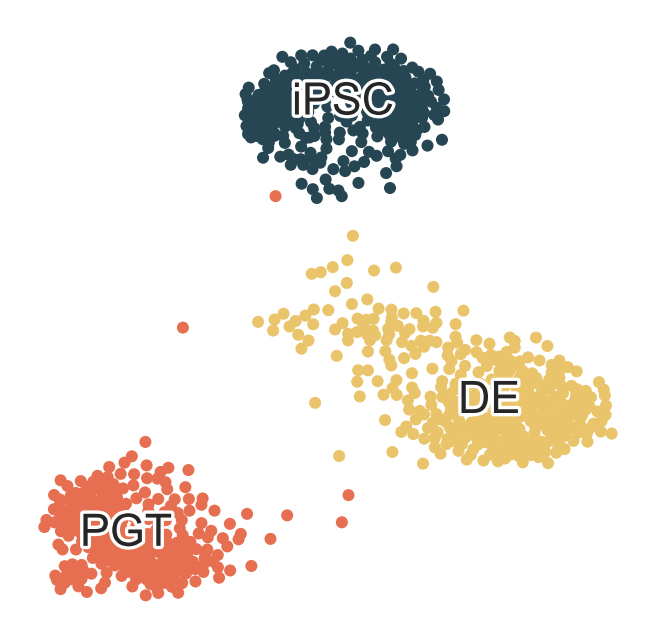

In [3]:
# Load scRNA-seq dataset
adata = sc.read_h5ad(f"{output_dir}/scRNA.h5ad")
print(adata)

with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.embedding(adata, basis="Harmony", frameon=False, color="Celltype", palette=palette, title="",
                    legend_loc="on data", legend_fontsize="x-large", legend_fontweight="normal", legend_fontoutline=3, show=True)

## Figure S5a. Dot plot of known marker genes

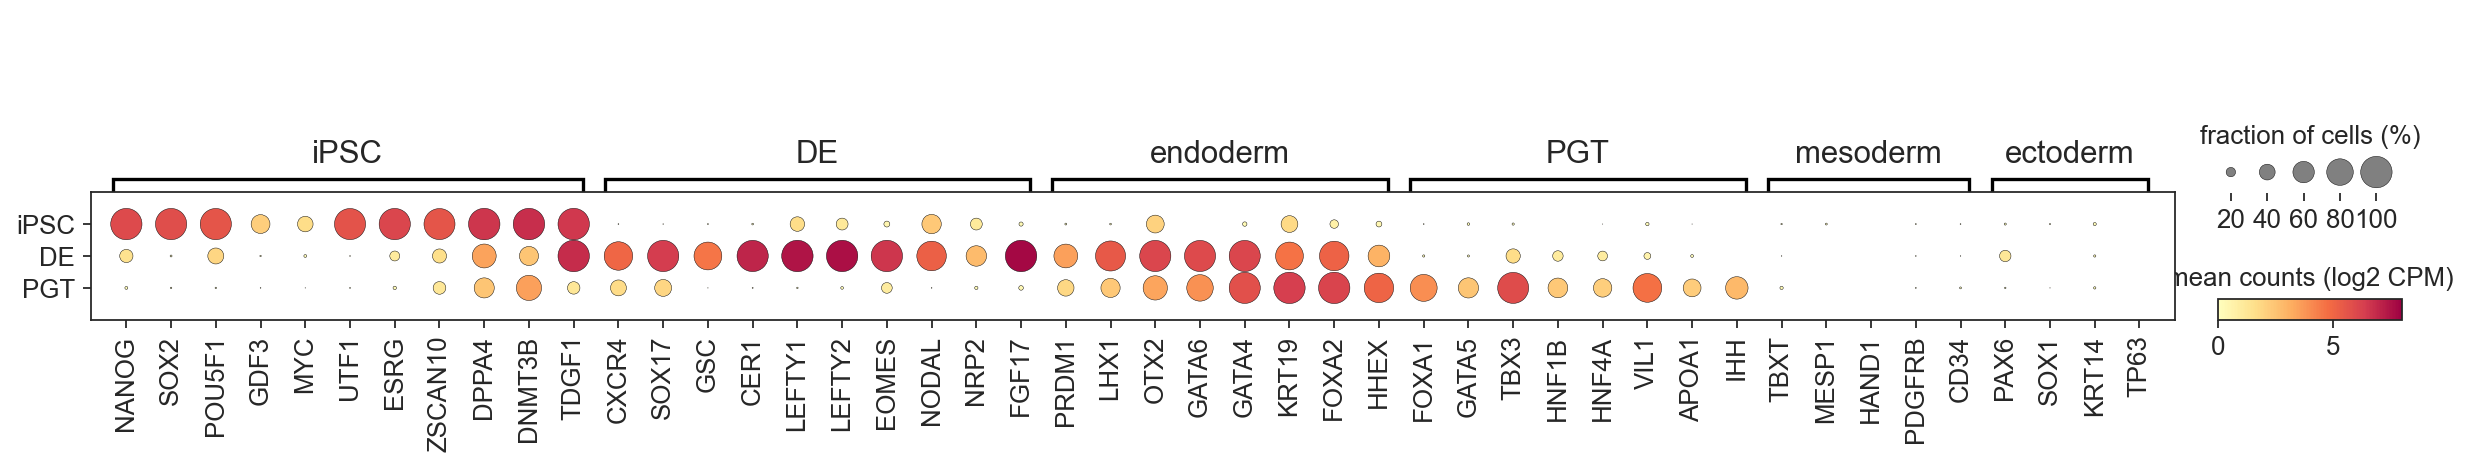

In [4]:
spectral_cmap = plt.cm.Spectral_r
sub_spectral_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("Spectral_r_truncated", spectral_cmap(np.linspace(0.5, 1, 256)))

with plt.rc_context({"patch.edgecolor": "black"}):
    sc.pl.dotplot(adata, groupby="Celltype", layer="CPM", log=True, show=False,
                  cmap=sub_spectral_cmap, vmin=0, vmax=8, var_group_rotation=0,
                  size_title="fraction of cells (%)", colorbar_title="mean counts (log2 CPM)",
                  var_names={"iPSC": ["NANOG", "SOX2", "POU5F1", "GDF3", "MYC", "UTF1", "ESRG", "ZSCAN10", "DPPA4", "DNMT3B", "TDGF1"], 
                             "DE": ["CXCR4", "SOX17", "GSC", "CER1", "LEFTY1", "LEFTY2", "EOMES", "NODAL", "NRP2", "FGF17"], #"ACKR3",  "MIXL1",
                             "endoderm": ["PRDM1", "LHX1", "OTX2", "GATA6", "GATA4", "KRT19", "FOXA2", "HHEX"],
                             "PGT": ["FOXA1", "GATA5", "TBX3", "HNF1B", "HNF4A", "VIL1", "APOA1", "IHH"], #"RFX6"
                             "mesoderm": ["TBXT", "MESP1", "HAND1", "PDGFRB", "CD34"], #"APLNR", 
                             "ectoderm": ["PAX6", "SOX1", "KRT14", "TP63"]}) #"DCX",
    plt.savefig(f"{output_dir}/SupplementalFigure5a.svg", format="svg")
    plt.show()

## Figure S6c. Dot plot of plotted genes

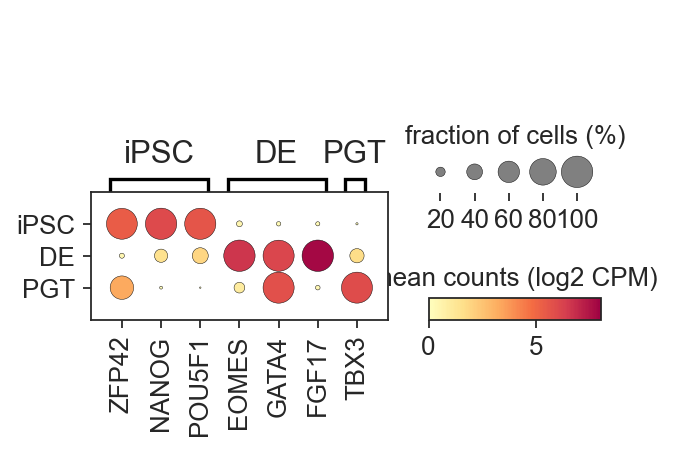

In [5]:
spectral_cmap = plt.cm.Spectral_r
sub_spectral_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("Spectral_r_truncated", spectral_cmap(np.linspace(0.5, 1, 256)))

with plt.rc_context({"patch.edgecolor": "black"}):
    sc.pl.dotplot(adata, groupby="Celltype", layer="CPM", log=True, show=False,
                  cmap=sub_spectral_cmap, vmin=0, vmax=8, var_group_rotation=0,
                  size_title="fraction of cells (%)", colorbar_title="mean counts (log2 CPM)",
                  var_names={"iPSC": ["ZFP42", "NANOG", "POU5F1"],
                             "DE": ["EOMES", "GATA4", "FGF17"],
                             "PGT": ["TBX3"]})
    plt.savefig(f"{output_dir}/SupplementalFigure6c_top.svg", format="svg")
    plt.show()

## Figure S5b. Silhouette scores

In [6]:
sil_all = silhouette_score(adata.obsm["X_pca"], adata.obs["Celltype"], metric="euclidean")
print(sil_all)

sil_samples = silhouette_samples(adata.obsm["X_pca"], adata.obs["Celltype"], metric="euclidean")
adata.obs["SilhouetteScore"] = sil_samples
display(adata.obs.groupby("Celltype")["SilhouetteScore"].mean())

0.58148825


Celltype
iPSC    0.733971
DE      0.446582
PGT     0.557249
Name: SilhouetteScore, dtype: float32

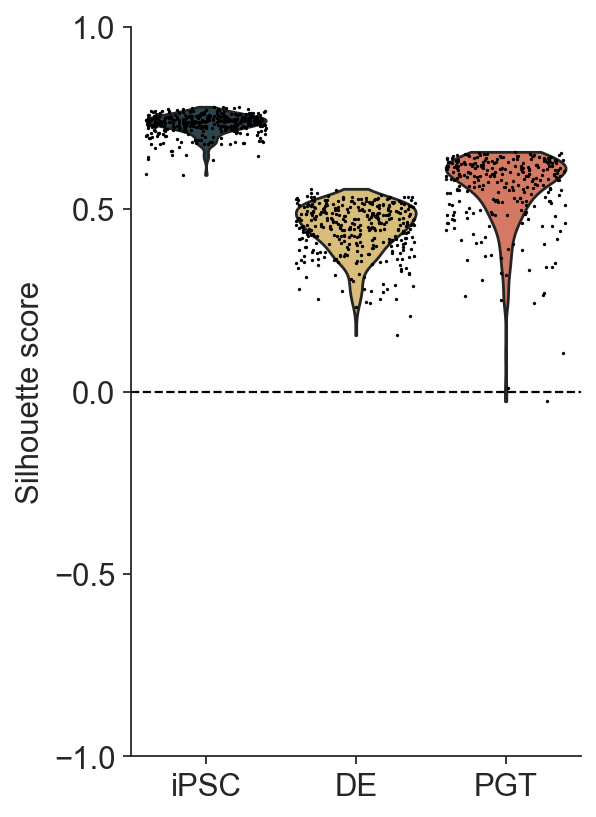

In [7]:
with plt.rc_context({"figure.figsize": (4, 6)}):
    sc.pl.violin(adata, keys="SilhouetteScore", groupby="Celltype", rotation=90, ylabel="Silhouette score", stripplot=True,  
        jitter=0.4, size=1.5, show=False)
    
    plt.ylim(-1, 1)
    plt.yticks([-1, -0.5, 0, 0.5, 1])
    plt.xticks(rotation=0)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.tight_layout()
    sns.despine()
    plt.savefig(f"{output_dir}/SupplementalFigure5b.svg", format="svg")
    plt.show()

## Figure 2d. Violin plots of DE and PGT signatures

Load the Excel file with Table S2 from [Xie et al. 2013](https://doi.org/10.1016/j.stem.2012.11.023) and import the lists of DE and PGT signature genes.

In [8]:
xls = pd.ExcelFile(f"{input_dir}/1-s2.0-S1934590912007060-mmc2.xls")
de_signature = xls.parse(sheet_name=0).iloc[:, 0].dropna().astype(str).tolist()[1:]
pgt_signature = xls.parse(sheet_name=1).iloc[:, 0].dropna().astype(str).tolist()[1:]

de_signature[:5], pgt_signature[:5]

(['ANKRD6', 'APLP2', 'ARRB1', 'BCAR3', 'BCL7C'],
 ['LGI2', 'PAQR9', 'SYTL5', 'SCN7A', 'CST4'])

In [9]:
signatures = {"DE": de_signature, "PGT": pgt_signature}

uc.compute_ucell_scores(adata, signatures=signatures)

/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: 

In [10]:
# Statistics
comparisons = [["DE", "iPSC", "DE"], ["DE", "DE", "PGT"], ["PGT", "DE", "PGT"]]
results = {}
for signature, x, y in comparisons:
    list_x = adata[adata.obs["Celltype"] == x].obs[f"{signature}_UCell"]
    list_y = adata[adata.obs["Celltype"] == y].obs[f"{signature}_UCell"]
    stat, p = scipy.stats.mannwhitneyu(list_x, list_y, alternative="two-sided", nan_policy="omit")
    results[f"{signature}: {x} vs {y}"] = {"stat": stat, "pval": p}

results_df = pd.DataFrame(results).T
results_df["padj"] = multipletests(results_df["pval"], method="bonferroni")[1]
display(results_df)

,stat,pval,padj
DE: iPSC vs DE,0.0,4.660564e-122,1.398169e-121
DE: DE vs PGT,104595.0,1.647292e-106,4.941875e-106
PGT: DE vs PGT,1.0,1.551430e-106,4.654291e-106


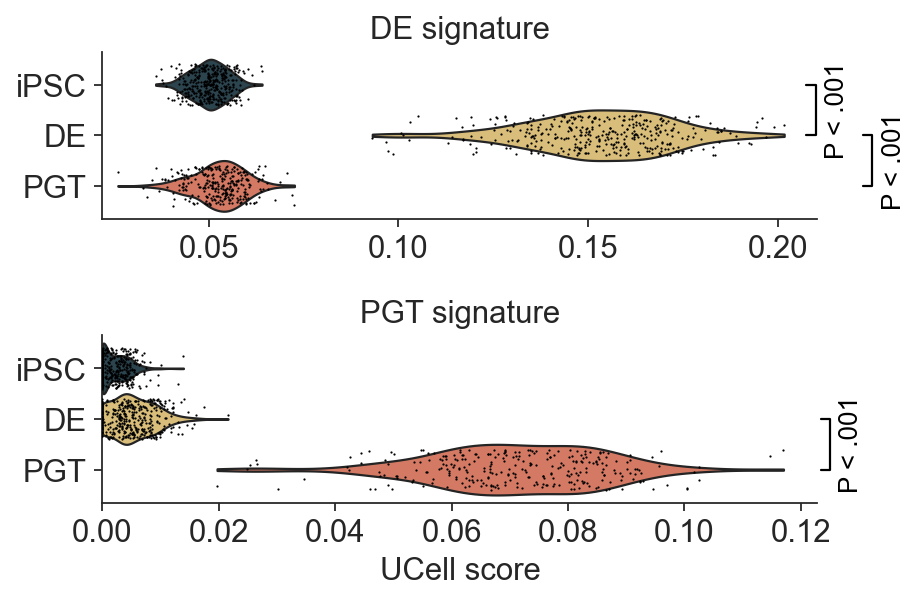

In [11]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 4))

for i, celltype in enumerate(["DE", "PGT"]):
    ucell_scores = adata.obs[["Celltype", f"{celltype}_UCell"]].melt(id_vars="Celltype", value_name="UCell_Score")
    
    sns.violinplot(data=ucell_scores, y="Celltype", hue="Celltype", x="UCell_Score", 
                   ax=axs[i], cut=0, linewidth=1, inner=None, palette=palette, width=1)
    sns.stripplot(data=ucell_scores, y="Celltype", x="UCell_Score", ax=axs[i], 
                  linewidth=0, jitter=0.4, s=1, color="black")
    
    axs[i].set(xlabel="", ylabel="", title=f"{celltype} signature")

# X axis range
axs[0].set(xlim=(0.022, None))
axs[1].set(xlim=(0, None))

## Add p-values
for ax_i, x1, x2, y, label in [[0, 0, 1, 0.21, "P < .001"], [0, 1, 2, 0.225, "P < .001"], [1, 1, 2, 0.125, "P < .001"]]:
    yh = 0.0025 if ax_i == 0 else 0.0015
    axs[ax_i].plot([y-yh, y, y, y-yh], [x1, x1, x2, x2], color="black", linewidth=1, clip_on=False)
    axs[ax_i].text(y+yh, (x1+x2)/2, label, ha="left", va="center", color="black", fontsize="small", rotation=90)

axs[1].set(xlabel="UCell score")

sns.despine()
plt.tight_layout() 
plt.savefig(f"{output_dir}/Figure2d.svg", format="svg")
plt.show()

## Figure S5c. DE and PGT signatures in PGT cells

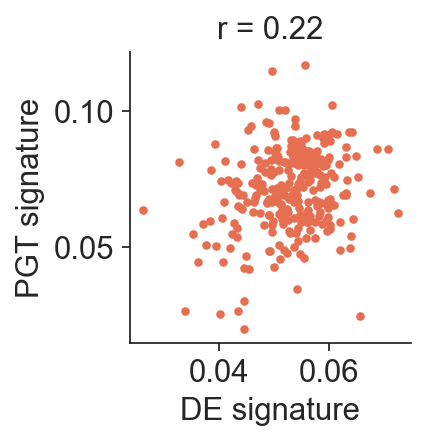

In [12]:
pgt_cells = adata.obs["Celltype"] == "PGT"
df = adata.obs.loc[pgt_cells, ["PGT_UCell", "DE_UCell"]].copy()

plt.figure(figsize=(3,3))
sns.scatterplot(x="DE_UCell", y="PGT_UCell", data=df, s=15, alpha=1, color=palette["PGT"], linewidth=0)

plt.xlabel("DE signature")
plt.ylabel("PGT signature")

## Add correlation coefficient
corr, _ = scipy.stats.pearsonr(df["DE_UCell"], df["PGT_UCell"])
plt.title(f"r = {corr:.2f}")

plt.tight_layout()
sns.despine()
plt.savefig(f"{output_dir}/SupplementalFigure5c.svg", format="svg")
plt.show()